In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)

from qae import QAEConfig, QuantumAutoencoder
from preprocessing import timed_preprocess

/Users/nicoletadobrica/AQA_QDL/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
prep = timed_preprocess(percent10=True, n_components=4, vis_samples=1000)

X_train = prep["X_train_pca"]
X_test = prep["X_test_pca"]
y_train = prep["y_train"]
y_test = prep["y_test"]

print("Full train:", X_train.shape)
print("Full test: ", X_test.shape)

Preprocessing time: 11.00s
Full train: (155644, 4)
Full test:  (98805, 4)


In [3]:
X_train_qae_full, X_val_qae, y_train_qae_full, y_val_qae = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

rng = np.random.default_rng(42)

train_subset_size = 6000 # 6000
train_idx = rng.choice(len(X_train_qae_full), size=train_subset_size, replace=False)
X_train_qae = X_train_qae_full[train_idx]
y_train_qae = y_train_qae_full[train_idx]

val_subset_size = 650 # 650
val_idx = rng.choice(len(X_val_qae), size=val_subset_size, replace=False)
X_val_qae_small = X_val_qae[val_idx]
y_val_qae_small = y_val_qae[val_idx]

print("QAE train subset:", X_train_qae.shape)
print("QAE val subset:  ", X_val_qae_small.shape)

QAE train subset: (6000, 4)
QAE val subset:   (650, 4)


In [ ]:
config = QAEConfig(
    n_qubits=4,
    n_latent=2,
    n_layers=1,
    device_name="default.qubit",
    seed=42,
    use_swap_test_loss=True,
    use_log_cost=True,
)

qae = QuantumAutoencoder(config)

best_params, history, scaler = qae.train(
    X_train_raw=X_train_qae,
    X_val_raw=X_val_qae_small,
    steps=80,  #80
    lr=0.03,
    batch_size=32, #32
    val_every=10, 
    verbose=True,
)

[Step 000] train_loss=-0.169546 | val_loss=-0.167978
[Step 005] train_loss=-0.188777
[Step 010] train_loss=-0.251801 | val_loss=-0.247944
[Step 015] train_loss=-0.333420
[Step 020] train_loss=-0.303894 | val_loss=-0.334859
[Step 025] train_loss=-0.334488
[Step 030] train_loss=-0.469309 | val_loss=-0.392310
[Step 035] train_loss=-0.336810
[Step 040] train_loss=-0.434386 | val_loss=-0.402897
[Step 045] train_loss=-0.439044
[Step 050] train_loss=-0.274736 | val_loss=-0.405581
[Step 055] train_loss=-0.463338
[Step 060] train_loss=-0.391230 | val_loss=-0.409362
[Step 065] train_loss=-0.470778
[Step 070] train_loss=-0.501317 | val_loss=-0.409794
[Step 075] train_loss=-0.445213
[Step 079] train_loss=-0.400870 | val_loss=-0.410390


In [5]:
qae.save_checkpoint(
    "qae_checkpoint.npz",
    params=best_params,
    scaler=scaler,
    history=history,
    extra_metadata={"dataset": "KDDCup99 PCA-4"}
)

In [6]:
qknn_train_size = 2000
qknn_test_size = 400

train_idx_small = rng.choice(len(X_train), size=qknn_train_size, replace=False)
test_idx_small = rng.choice(len(X_test), size=qknn_test_size, replace=False)

X_train_small = X_train[train_idx_small]
y_train_small = y_train[train_idx_small]

X_test_small = X_test[test_idx_small]
y_test_small = y_test[test_idx_small]

In [ ]:
import pennylane as qml
from pennylane import numpy as np

def apply_trained_encoder(params, wires, n_layers):
    """Apply the trained QAE encoder circuit on specific wires."""
    n_qubits = len(wires)
    
    for layer in range(n_layers):
        for i, w in enumerate(wires):
            qml.RY(params[layer, i, 0], wires=w)
            qml.RZ(params[layer, i, 1], wires=w)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[wires[i], wires[i + 1]])
        qml.CNOT(wires=[wires[-1], wires[0]])

In [ ]:
import json
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

def build_qknn_swap_test(qae_inst):
    n_q = qae_inst.config.n_qubits
    n_latent = qae_inst.config.n_latent

    dev = qml.device("default.qubit", wires=1 + 2 * n_q)

    @qml.qnode(dev)
    def circuit(x1, x2, params):
        ancilla = 0
        reg1 = list(range(1, n_q + 1))
        reg2 = list(range(n_q + 1, 2 * n_q + 1))

        # Encode + apply trained encoder (REGISTER 1)
        qml.AngleEmbedding(x1, wires=reg1, rotation="Y")
        apply_trained_encoder(params, reg1, qae_inst.config.n_layers)

        # Encode + apply trained encoder (REGISTER 2)
        qml.AngleEmbedding(x2, wires=reg2, rotation="Y")
        apply_trained_encoder(params, reg2, qae_inst.config.n_layers)

        # swap test on latent qubits only
        qml.Hadamard(wires=ancilla)
        for i in range(n_latent):
            qml.CSWAP(wires=[ancilla, reg1[i], reg2[i]])
        qml.Hadamard(wires=ancilla)

        return qml.probs(wires=[ancilla])

    return circuit

In [ ]:
def compute_fidelity_matrix(qnode, X_test, X_train, params):
    n_test = len(X_test)
    n_train = len(X_train)

    fidelities = np.zeros((n_test, n_train))

    for i in range(n_test):
        xt = X_test[i]
        for j in range(n_train):
            probs = qnode(xt, X_train[j], params)
            fidelities[i, j] = np.clip(2 * probs[0] - 1, 0.0, 1.0)

        if (i + 1) % 20 == 0:
            print(f"Processed {i+1}/{n_test}")

    return fidelities

In [10]:
from collections import Counter
def qknn_predict(fidelity_matrix, y_train, k=3):
    y_pred = []
    y_prob = []

    for row in fidelity_matrix:
        idx = np.argsort(row)[-k:]
        labels = y_train[idx]

        y_pred.append(Counter(labels).most_common(1)[0][0])
        y_prob.append(np.mean(labels))

    return np.array(y_pred), np.array(y_prob)

In [ ]:
qknn_test_n = 400
qknn_train_n = 2000

X_te_angles = qae.transform_to_angles(X_test_small[:qknn_test_n], scaler)
X_tr_angles = qae.transform_to_angles(X_train_small[:qknn_train_n], scaler)

y_tr_labels = y_train_small[:qknn_train_n]
y_te_true = y_test_small[:qknn_test_n]

qknn_qnode = build_qknn_swap_test(qae)

print(f"Running optimized QkNN for {qknn_test_n} samples...")

F = compute_fidelity_matrix(qknn_qnode, X_te_angles, X_tr_angles, best_params)

y_pred_qknn, y_prob_qknn = qknn_predict(F, y_tr_labels, k=3)

Running optimized QkNN for 400 samples...
Processed 20/400
Processed 40/400
Processed 60/400
Processed 80/400
Processed 100/400
Processed 120/400
Processed 140/400
Processed 160/400
Processed 180/400
Processed 200/400
Processed 220/400
Processed 240/400
Processed 260/400
Processed 280/400
Processed 300/400
Processed 320/400
Processed 340/400
Processed 360/400
Processed 380/400
Processed 400/400


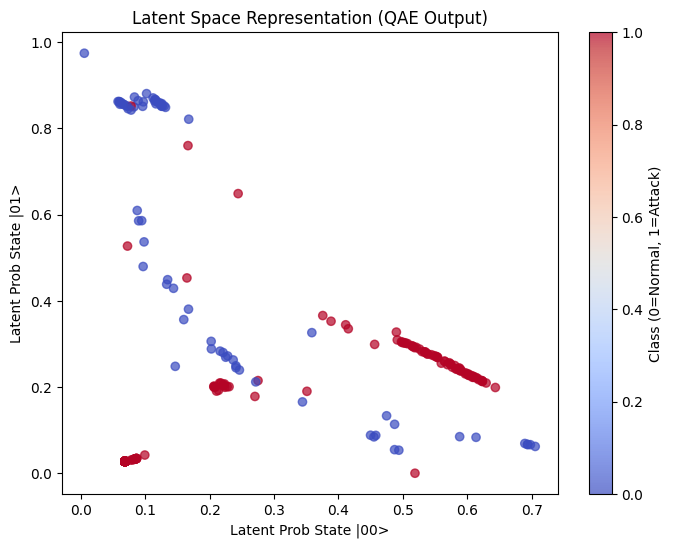

In [ ]:
import matplotlib.pyplot as plt

def get_latent_features(qae_model, X_angles, params):
    """Extracts the probability distribution of the latent qubits."""
    n_q = qae_model.config.n_qubits
    n_latent = qae_model.config.n_latent
    
    dev_latent = qml.device("default.qubit", wires=n_q)
    
    @qml.qnode(dev_latent)
    def latent_circuit(x):
        qml.AngleEmbedding(x, wires=range(n_q), rotation="Y")
        # Apply the trained encoder block
        apply_trained_encoder(params, range(n_q), qae_model.config.n_layers)
        # Return the probabilities of the latent qubits only
        return qml.probs(wires=range(n_latent))

    latent_reps = np.array([latent_circuit(x) for x in X_angles])
    return latent_reps

latent_features = get_latent_features(qae, X_te_angles, best_params)

plt.figure(figsize=(8, 6))
plt.scatter(latent_features[:, 0], latent_features[:, 1], c=y_te_true, cmap='coolwarm', alpha=0.7)
plt.title("Latent Space Representation (QAE Output)")
plt.xlabel("Latent Prob State |00>")
plt.ylabel("Latent Prob State |01>")
plt.colorbar(label="Class (0=Normal, 1=Attack)")
plt.show()


Accuracy: 0.9550 | ROC-AUC: 0.9670


,precision,recall,f1-score,support
normal,0.8481,0.9178,0.8816,73.000
attack,0.9813,0.9633,0.9722,327.000
accuracy,0.9550,0.9550,0.9550,0.955
macro avg,0.9147,0.9406,0.9269,400.000
weighted avg,0.9570,0.9550,0.9557,400.000


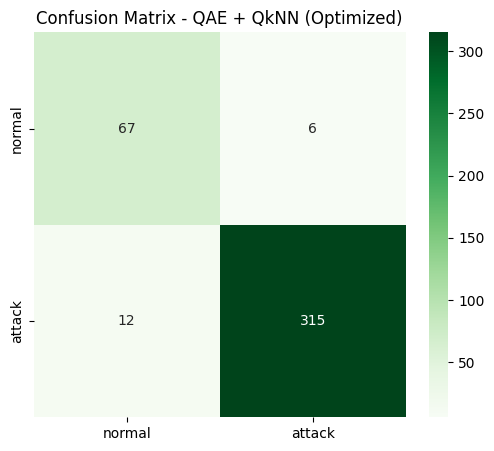

Extracting latent clusters for visualization...


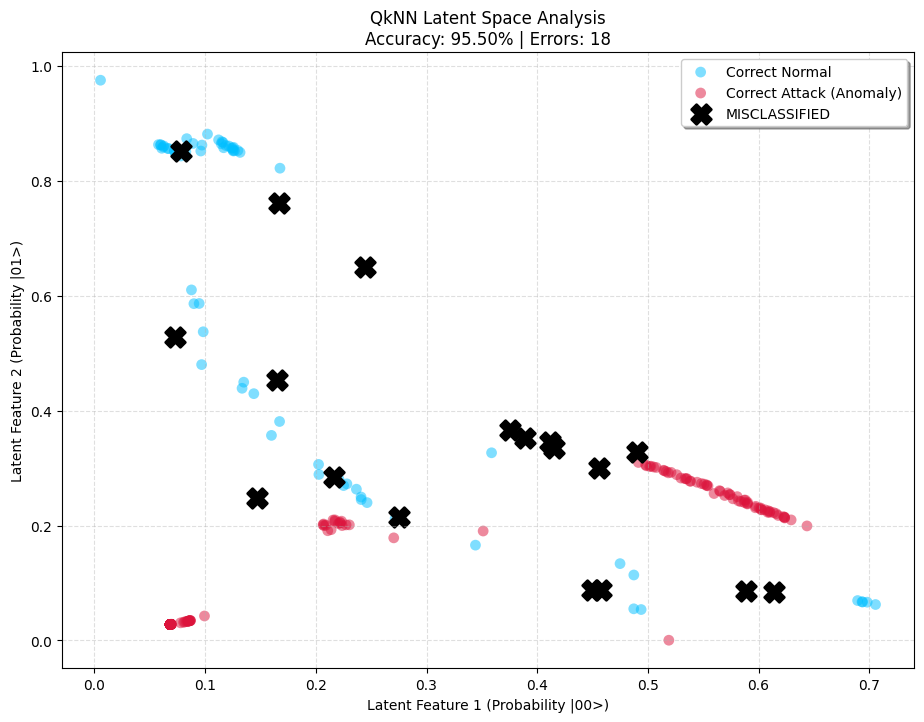

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score
)

y_te_true_int = np.array(y_te_true, dtype=int)
y_pred_qknn_int = np.array(y_pred_qknn, dtype=int)

acc_qknn = accuracy_score(y_te_true_int, y_pred_qknn_int)
auc_qknn = roc_auc_score(y_te_true_int, y_prob_qknn)
cm_qknn = confusion_matrix(y_te_true_int, y_pred_qknn_int)

report_qknn = pd.DataFrame(classification_report(
    y_te_true_int,
    y_pred_qknn_int,
    target_names=["normal", "attack"],
    output_dict=True
)).T

print(f"\nAccuracy: {acc_qknn:.4f} | ROC-AUC: {auc_qknn:.4f}")
display(report_qknn.round(4))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_qknn, annot=True, fmt="d", cmap="Greens",
            xticklabels=["normal", "attack"],
            yticklabels=["normal", "attack"])
plt.title("Confusion Matrix - QAE + QkNN (Optimized)")
plt.show()


def visualize_qknn_results(qae_inst, X_angles, y_true, y_pred, params):
    """
    Plots the 2D Latent Clusters.
    """
    n_q = qae_inst.config.n_qubits
    n_lat = qae_inst.config.n_latent
    
    dev_latent = qml.device("default.qubit", wires=n_q)
    
    @qml.qnode(dev_latent)
    def encode_to_latent(x):
        qml.AngleEmbedding(x, wires=range(n_q), rotation="Y")
        # Apply trained encoder
        apply_trained_encoder(params, range(n_q), qae_inst.config.n_layers)
        # Returns probabilities of the latent qubits
        return qml.probs(wires=range(n_lat))

    print("Extracting latent clusters for visualization...")
    lat_output = np.array([encode_to_latent(x) for x in X_angles])
    x_coords = lat_output[:, 0] 
    y_coords = lat_output[:, 1]
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    correct_mask = (y_true == y_pred)
    error_mask = (y_true != y_pred)

    plt.figure(figsize=(11, 8))

    plt.scatter(x_coords[correct_mask & (y_true == 0)], 
                y_coords[correct_mask & (y_true == 0)], 
                c='deepskyblue', label='Correct Normal', alpha=0.5, s=60, edgecolors='none')
    plt.scatter(x_coords[correct_mask & (y_true == 1)], 
                y_coords[correct_mask & (y_true == 1)], 
                c='crimson', label='Correct Attack (Anomaly)', alpha=0.5, s=60, edgecolors='none')
    plt.scatter(x_coords[error_mask], 
                y_coords[error_mask], 
                c='black', marker='X', s=200, label='MISCLASSIFIED', linewidth=2)

    plt.title(f"QkNN Latent Space Analysis\nAccuracy: {acc_qknn:.2%} | Errors: {np.sum(error_mask)}")
    plt.xlabel("Latent Feature 1 (Probability |00>)")
    plt.ylabel("Latent Feature 2 (Probability |01>)")
    plt.legend(loc='upper right', frameon=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.4)
    
    plt.show()
visualize_qknn_results(qae, X_te_angles, y_te_true_int, y_pred_qknn_int, best_params)